In [2]:
import os
import glob
import numpy as np
import pandas as pd

def load_HuGaDB_file(path_to_file):
    """Read HuGaDB data from file and get numpy matrix."""
    return np.genfromtxt(path_to_file, delimiter='\t', skip_header=4)

def compile_dataset_to_dataframe(folder_path):
    """
    Loops through all .txt files in a folder, extracts the data,
    and compiles it into a single Pandas DataFrame.
    """
    all_data_frames = []

    # 1. Find all .txt files in the specified directory
    # Using glob makes it easy to grab specific file types
    search_pattern = os.path.join(folder_path, "*.txt")
    file_paths = glob.glob(search_pattern)

    if not file_paths:
        print(f"Warning: No .txt files found in '{folder_path}'")
        return pd.DataFrame()

    print(f"Found {len(file_paths)} files. Beginning extraction...")

    # 2. Loop through the files
    for file_path in file_paths:
        try:
            # Extract the raw numpy matrix
            data_matrix = load_HuGaDB_file(file_path)

            # Convert the matrix to a temporary DataFrame
            temp_df = pd.DataFrame(data_matrix)


            # Append the temporary dataframe to our fast Python list
            all_data_frames.append(temp_df)

        except Exception as e:
            print(f"Error processing {os.path.basename(file_path)}: {e}")

    # 3. Concatenate the list into a single massive DataFrame at the very end
    print("Concatenating data...")
    final_df = pd.concat(all_data_frames, ignore_index=True)

    return final_df

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    # Point this to the folder containing your HuGaDB .txt files
    data_folder = "/content/data/"

    # Compile the data
    df = compile_dataset_to_dataframe(data_folder)

    if not df.empty:
        print("\n--- Extraction Complete ---")
        print(f"Total rows: {len(df)}")
        print(f"Total columns: {len(df.columns)}")
        print("\nFirst 5 rows:")
        print(df.head())

Found 635 files. Beginning extraction...
Concatenating data...

--- Extraction Complete ---
Total rows: 2111962
Total columns: 39

First 5 rows:
       0       1        2      3     4      5        6       7       8   \
0 -8908.0 -3212.0  13732.0   34.0  20.0 -162.0 -15756.0  2048.0 -3632.0   
1 -9012.0 -3148.0  13716.0   52.0 -45.0 -115.0 -15812.0  2064.0 -3712.0   
2 -9016.0 -3128.0  13736.0   47.0  24.0 -111.0 -15680.0  2076.0 -3624.0   
3 -8956.0 -3124.0  13712.0  101.0  -2.0 -128.0 -15708.0  2044.0 -3600.0   
4 -8964.0 -3204.0  13744.0  101.0 -25.0  -92.0 -15800.0  2000.0 -3556.0   

      9   ...     29       30     31      32    33    34    35     36     37  \
0  -95.0  ...   63.0 -16324.0  -16.0 -1092.0  65.0  43.0 -75.0  126.0  127.0   
1 -142.0  ...   44.0 -16320.0    0.0 -1092.0  45.0  91.0 -51.0  127.0  127.0   
2 -182.0  ...  119.0 -16344.0 -116.0 -1124.0  72.0 -15.0 -23.0  129.0  127.0   
3  -52.0  ...   93.0 -16348.0    8.0 -1072.0  46.0 -40.0  34.0  125.0  127.0   
4   

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==========================================
# 1. ICBAM: Improved Convolutional Block Attention Module
# ==========================================
def channel_attention_1d(inputs, reduction_ratio=8):
    """1D version of the Channel Attention Module."""
    channels = inputs.shape[-1]

    # Paper uses Average and Max pooling [cite: 321]
    avg_pool = layers.GlobalAveragePooling1D(keepdims=True)(inputs)
    max_pool = layers.GlobalMaxPooling1D(keepdims=True)(inputs)

    # Shared MLP [cite: 320]
    shared_layer1 = layers.Dense(channels // reduction_ratio, activation='relu')
    shared_layer2 = layers.Dense(channels)

    avg_out = shared_layer2(shared_layer1(avg_pool))
    max_out = shared_layer2(shared_layer1(max_pool))

    out = layers.Add()([avg_out, max_out])
    attention = layers.Activation('sigmoid')(out)
    return layers.Multiply()([inputs, attention])

def spatial_attention_1d(inputs):
    """
    1D Spatial (Temporal) Attention.
    The paper improves this by replacing standard conv with Depthwise Separable Convolution.
    """
    # FIX: Wrap the raw tf operations inside a Keras Lambda layer
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(inputs)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(inputs)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    # DSC substitution as requested by the paper
    depthwise = layers.DepthwiseConv1D(kernel_size=7, padding='same')(concat)
    pointwise = layers.Conv1D(filters=1, kernel_size=1, padding='same')(depthwise)

    attention = layers.Activation('sigmoid')(pointwise)
    return layers.Multiply()([inputs, attention])

def icbam_1d(inputs):
    """
    The paper's ICBAM connects Channel and Spatial attention in PARALLEL
    rather than sequentially.
    """
    channel_out = channel_attention_1d(inputs)
    spatial_out = spatial_attention_1d(inputs)

    # Parallel connection fusion
    fused_attention = layers.Add()([channel_out, spatial_out])
    return layers.Multiply()([inputs, fused_attention])

# ==========================================
# 2. Lightweight Backbone (1D MobileNetV2 Block)
# ==========================================
def mobilenet_v2_1d_block(x, filters, stride, expansion=4):
    """Inverted Residual Block adapted for 1D[cite: 275]."""
    in_channels = x.shape[-1]

    # Pointwise expansion
    y = layers.Conv1D(in_channels * expansion, 1, padding='same', use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU(max_value=6)(y)

    # Depthwise feature extraction
    y = layers.DepthwiseConv1D(kernel_size=3, strides=stride, padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU(max_value=6)(y)

    # Pointwise linear projection [cite: 277]
    y = layers.Conv1D(filters, 1, padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)

    # Shortcut connection if shapes match [cite: 279]
    if stride == 1 and in_channels == filters:
        return layers.Add()([x, y])
    return y

# ==========================================
# 3. Main Model Assembly
# ==========================================
def build_paper_architecture_1d(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution
    x = layers.Conv1D(32, 3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6)(x)

    # Build a small MobileNetV2-like backbone
    x = mobilenet_v2_1d_block(x, filters=32, stride=1)
    x = mobilenet_v2_1d_block(x, filters=64, stride=2)
    backbone_features = mobilenet_v2_1d_block(x, filters=64, stride=1)

    # --- DUAL BRANCH STRUCTURE [cite: 255] ---
    # Branch 1: Convolutional Branch (Raw backbone features) [cite: 256]
    conv_branch = backbone_features

    # Branch 2: Attention Branch (ICBAM focuses on backbone features) [cite: 257]
    attention_branch = icbam_1d(backbone_features)

    # Feature Fusion [cite: 259]
    fused_features = layers.Add()([conv_branch, attention_branch])

    # --- CUSTOMIZED HEAD  ---
    # The paper replaces Global Average Pooling with a Depthwise Separable Convolution
    head = layers.DepthwiseConv1D(kernel_size=3, padding='valid')(fused_features)
    head = layers.Conv1D(filters=128, kernel_size=1, padding='same')(head) # Pointwise completion

    head = layers.Flatten()(head)
    head = layers.Dense(128)(head)
    head = layers.BatchNormalization()(head)
    head = layers.ReLU()(head)
    head = layers.Dropout(0.3)(head) # Paper explicitly specifies p=0.4 dropout [cite: 143]

    outputs = layers.Dense(num_classes, activation='softmax')(head)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Paper's learning rate [cite: 399]
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats

def preprocess_dataframe(df, window_size=100, step_size=50):
    """
    Extracts 3D windows continuously from the entire DataFrame
    without grouping by source file.
    """
    X_windows = []
    y_labels = []

    # Convert the entire dataframe to a numpy array for much faster processing
    data_matrix = df.values

    # Slide the window across the entire dataset
    for i in range(0, len(data_matrix) - window_size, step_size):
        window = data_matrix[i:i + window_size]

        # Sensors are all columns except the last one
        sensors_data = window[:, :-1]

        # The label is the last column
        labels_data = window[:, -1]

        X_windows.append(sensors_data)

        # Assign the most frequent label in this 2-second window
        mode_result = stats.mode(labels_data, keepdims=False)
        y_labels.append(mode_result.mode)

    return np.array(X_windows), np.array(y_labels)

def train_and_evaluate_pipeline(df):
    """
    Executes the full machine learning pipeline from DataFrame to trained model.
    """
    print("--- 1. Windowing Data ---")
    X, y = preprocess_dataframe(df, window_size=100, step_size=50)
    print(f"Extracted {X.shape[0]} windows of shape {X.shape[1:]}")

    print("\n--- 2. Encoding Labels ---")
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    num_classes = len(np.unique(y_encoded))
    print(f"Detected {num_classes} unique classes: {label_encoder.classes_}")

    print("\n--- 3. Splitting Data ---")
    # 'stratify=y_encoded' ensures the train/test split maintains the same proportion
    # of normal vs pathological gaits as the original dataset.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print("\n--- 4. Scaling Sensor Data ---")
    # Neural networks are highly sensitive to unscaled IMU/EMG data.
    # We must reshape to 2D -> Scale -> Reshape back to 3D for the CNN.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    print("\n--- 5. Initializing Model ---")
    input_shape = (X_train.shape[1], X_train.shape[2])

    # IMPORTANT: Call the model function you defined in the previous step here
    model = build_paper_architecture_1d(input_shape, num_classes)

    # Training Callbacks
    callbacks = [
        # Stop training if validation loss hasn't improved in 10 epochs
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        ),
        # Gradually reduce the learning rate if the model gets stuck
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
        )
    ]

    print("\n--- 6. Training Model ---")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=50, # Set to 50, but EarlyStopping will likely halt it sooner
        batch_size=32,
        validation_split=0.2, # Use 20% of training data for internal validation
        callbacks=callbacks,
        verbose=1
    )

    print("\n--- 7. Final Evaluation ---")
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

    # Generate detailed breakdown
    from sklearn.metrics import classification_report
    y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
    original_y_test = label_encoder.inverse_transform(y_test)
    original_y_pred = label_encoder.inverse_transform(y_pred)
    print("\nClassification Report:")
    print(classification_report(original_y_test, original_y_pred))

    return model, history, scaler, label_encoder


trained_model, training_history, data_scaler, encoder = train_and_evaluate_pipeline(df)

--- 1. Windowing Data ---
Extracted 42238 windows of shape (100, 38)

--- 2. Encoding Labels ---
Detected 12 unique classes: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]

--- 3. Splitting Data ---

--- 4. Scaling Sensor Data ---

--- 5. Initializing Model ---

--- 6. Training Model ---
Epoch 1/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.7076 - loss: 0.9336 - val_accuracy: 0.8615 - val_loss: 0.4216 - learning_rate: 1.0000e-04
Epoch 2/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8632 - loss: 0.4099 - val_accuracy: 0.8862 - val_loss: 0.2930 - learning_rate: 1.0000e-04
Epoch 3/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8798 - loss: 0.3283 - val_accuracy: 0.8921 - val_loss: 0.2642 - learning_rate: 1.0000e-04
Epoch 4/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8888 - loss: 0.2913 - val_accuracy: 0.8966 - val_loss: 0.2520 - learning_rate: 1.0000e-04
Epoch 5/50
845/845 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8968 - loss: 0.2

In [5]:
from sklearn.model_selection import train_test_split

print("Reconstructing data splits for evaluation...")

# 1. Re-extract the windows (This is fast)
X, y = preprocess_dataframe(df, window_size=100, step_size=50)

# 2. Re-encode labels using the encoder we saved from the training step
y_encoded = encoder.transform(y)

# 3. Re-split with the EXACT SAME random_state=42 so it perfectly matches your trained model
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. Re-scale the data using the EXACT SAME scaler we saved from the training step
X_train_scaled = data_scaler.transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = data_scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

print("Variables successfully reconstructed! You can now run the evaluation block.")

Reconstructing data splits for evaluation...
Variables successfully reconstructed! You can now run the evaluation block.


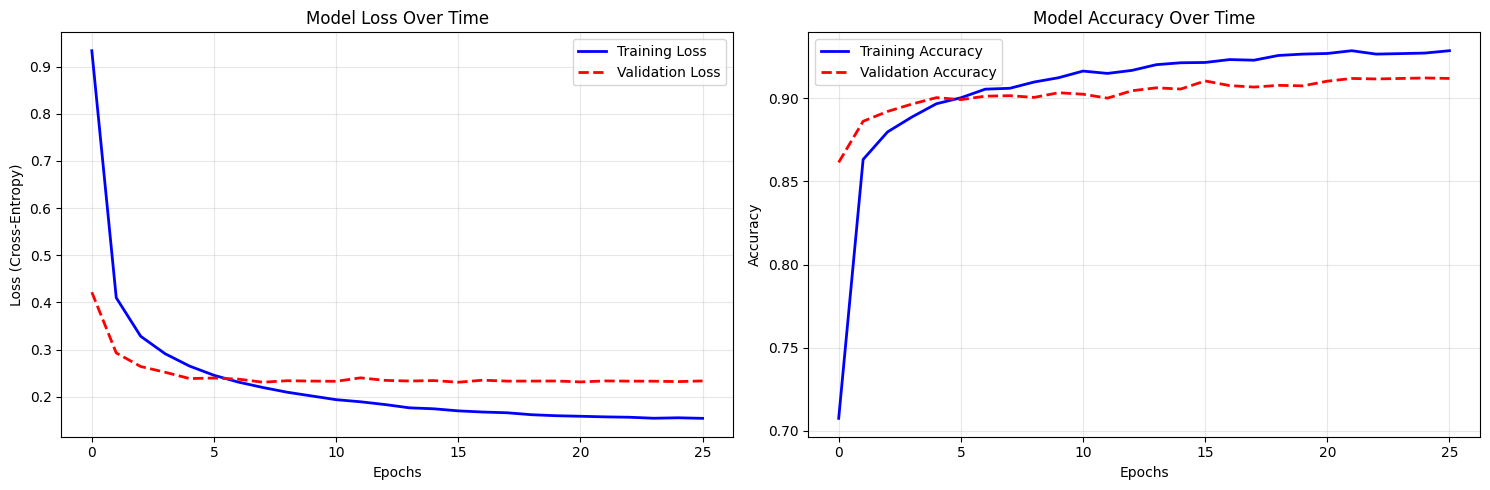


--- Training Baseline Model (Logistic Regression) ---

                MODEL COMPARISON TABLE                 
                         Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
Baseline (LogReg)          0.8458             0.7591          0.7484            0.7505
Proposed Advanced Model    0.9094             0.8594          0.8404            0.8422



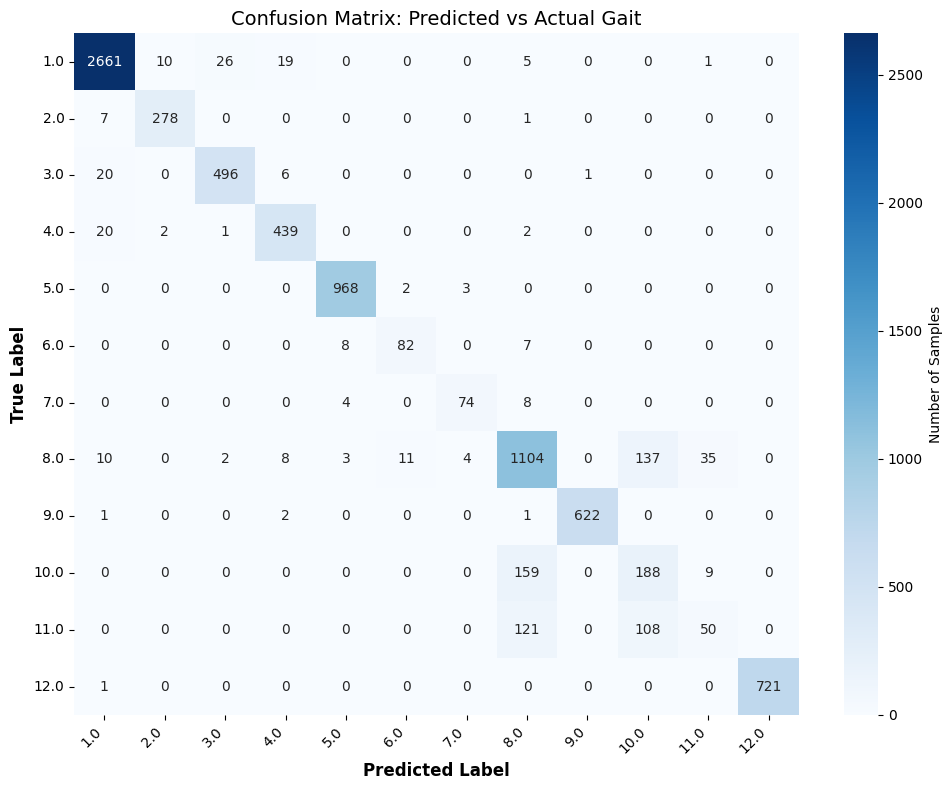


    DETAILED CLASSIFICATION REPORT (ADVANCED MODEL)    
              precision  recall  f1-score    support
1.0              0.9783  0.9776    0.9779  2722.0000
2.0              0.9586  0.9720    0.9653   286.0000
3.0              0.9448  0.9484    0.9466   523.0000
4.0              0.9262  0.9461    0.9360   464.0000
5.0              0.9847  0.9949    0.9898   973.0000
6.0              0.8632  0.8454    0.8542    97.0000
7.0              0.9136  0.8605    0.8862    86.0000
8.0              0.7841  0.8402    0.8112  1314.0000
9.0              0.9984  0.9936    0.9960   626.0000
10.0             0.4342  0.5281    0.4766   356.0000
11.0             0.5263  0.1792    0.2674   279.0000
12.0             1.0000  0.9986    0.9993   722.0000
accuracy         0.9094  0.9094    0.9094     0.9094
macro avg        0.8594  0.8404    0.8422  8448.0000
weighted avg     0.9067  0.9094    0.9049  8448.0000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. Plotting Training & Validation Curves
# ==========================================
def plot_learning_curves(history):
    """Plots the loss and accuracy curves to diagnose overfitting/underfitting."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Curve
    axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[0].set_title('Model Loss Over Time')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Cross-Entropy)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy Curve
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Model Accuracy Over Time')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# 2. Confusion Matrix
# ==========================================
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Generates a highly visual heatmap of the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Number of Samples'})

    plt.title('Confusion Matrix: Predicted vs Actual Gait', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. Base Model Comparison (Logistic Regression)
# ==========================================
def run_baseline_comparison(X_train_scaled, y_train, X_test_scaled, y_test, advanced_model, label_encoder):
    """
    Trains a simple baseline model (Logistic Regression) and compares its
    performance against your advanced 1D-CNN/Transformer.
    """
    print("\n--- Training Baseline Model (Logistic Regression) ---")

    # Standard ML models require 2D data (Samples x Features)
    # We must flatten the 3D sequence data (Samples x Time x Sensors) into 2D
    X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
    X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

    # Initialize and train base model
    base_model = LogisticRegression(max_iter=1000, random_state=42)
    base_model.fit(X_train_flat, y_train)
    base_pred = base_model.predict(X_test_flat)

    # Get predictions for your advanced model
    adv_pred_probs = advanced_model.predict(X_test_scaled, verbose=0)
    adv_pred = np.argmax(adv_pred_probs, axis=1)

    # Calculate Metrics for Both Models
    metrics = {
        'Accuracy': [accuracy_score(y_test, base_pred), accuracy_score(y_test, adv_pred)],
        'Precision (Macro)': [precision_score(y_test, base_pred, average='macro', zero_division=0),
                              precision_score(y_test, adv_pred, average='macro', zero_division=0)],
        'Recall (Macro)': [recall_score(y_test, base_pred, average='macro', zero_division=0),
                           recall_score(y_test, adv_pred, average='macro', zero_division=0)],
        'F1-Score (Macro)': [f1_score(y_test, base_pred, average='macro', zero_division=0),
                             f1_score(y_test, adv_pred, average='macro', zero_division=0)]
    }

    # Compile into a Pandas DataFrame for a clean table
    comparison_df = pd.DataFrame(metrics, index=['Baseline (LogReg)', 'Proposed Advanced Model']).round(4)

    print("\n=======================================================")
    print("                MODEL COMPARISON TABLE                 ")
    print("=======================================================")
    print(comparison_df.to_string())
    print("=======================================================\n")

    return base_pred, adv_pred

# ==========================================
# Execution & Discussion Generation
# ==========================================
# Assuming these variables exist from your previous training step:
# history, trained_model, X_train_scaled, y_train, X_test_scaled, y_test, encoder

# 1. Plot the Learning Curves
plot_learning_curves(training_history)

# 2. Run Comparison and get predictions
base_pred, adv_pred = run_baseline_comparison(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    trained_model, encoder
)

# 3. Plot the Confusion Matrix for the Advanced Model
original_y_test = encoder.inverse_transform(y_test)
original_adv_pred = encoder.inverse_transform(adv_pred)
plot_confusion_matrix(original_y_test, original_adv_pred, encoder.classes_)

# 4. Generate Detailed Classification Report (Per-Class Table)
print("\n=======================================================")
print("    DETAILED CLASSIFICATION REPORT (ADVANCED MODEL)    ")
print("=======================================================")
report_dict = classification_report(original_y_test, original_adv_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().round(4)
print(report_df.to_string())